# kitscenes — Quickstart Demo

This notebook demonstrates the core functionality of the `kitscenes` API:

1. Loading the dataset
2. Listing and inspecting scenes
3. Accessing timestamps, ego poses, and sensor metadata

**Prerequisite:** Set `KITSCENES_ROOT` or edit the `DATASET_ROOT` variable below.

In [1]:
# -- Configuration --------------------------------------------------------

# Option B: Hard-code the path here since we are in a notebook (has to be an absolute path):
DATASET_ROOT = "/tmp/fehler/ratarmount/kitscenes"
SCENE_ID = "c34c778f-ad8c-0aa9-7e1a-c86a73f887c7"  # sample val scene

## 1. Load the dataset

In [2]:
from kitscenes import KITScenesDataset

# Pass root= explicitly (or omit it to use $KITSCENES_ROOT).
# This path already points at the train dataset root, so keep split=None.
ds = KITScenesDataset(root=DATASET_ROOT, split=None)
print(ds)
print(f"Number of scenes: {len(ds)}")

KITScenesDataset(root=PosixPath('/tmp/fehler/ratarmount/kitscenes'), split=None, num_scenes=11)
Number of scenes: 11


## 2. List available scenes

In [3]:
# scene_ids returns a sorted list of directory names
print("All scene IDs:")
for sid in ds.scene_ids:
    print(f"  {sid}")

All scene IDs:
  008fba36-5e82-e02b-8edf-a55f5271758d
  00efe646-1e8f-cadc-d642-e676781187ef
  00fc1b9b-005e-554c-7733-c4c0adeca015
  02be7d74-6f74-9167-c8a2-84fc961c0fbd
  03ed2585-0729-92ad-98af-fdd9ac1c3a80
  04a39028-c434-6cff-b3f4-9f8dbb9aa078
  0638dbd2-172d-142e-de9f-9bc5c6ca2b0f
  0cfdeb83-2a4a-00d2-a500-787346d98e63
  0dd003b2-0988-0da3-bf75-ee91deaa9ce6
  0f8ffa88-e84d-eaa2-4ef1-62bb539f8e03
  c34c778f-ad8c-0aa9-7e1a-c86a73f887c7


## 3. Load and inspect a single scene

In [4]:
if SCENE_ID not in ds.scene_ids:
    raise ValueError(f"Scene {SCENE_ID!r} not found under {DATASET_ROOT}")

scene = ds.get_scene(SCENE_ID)

print(f"Scene ID:   {scene.scene_id}")
print(f"Scene path: {scene.scene_path}")
print(f"Frames:     {scene.metadata.num_frames}")
print(f"Duration:   {scene.metadata.duration_s:.2f} s")
print(f"Sensors:    {scene.metadata.sensor_names}")

Scene ID:   008fba36-5e82-e02b-8edf-a55f5271758d
Scene path: /tmp/fehler/ratarmount/kitscenes/data/train/008fba36-5e82-e02b-8edf-a55f5271758d
Frames:     130
Duration:   12.90 s
Sensors:    ('camera_base_front_center', 'camera_base_front_left_rect', 'camera_base_front_right_rect', 'camera_ring_front', 'camera_ring_front_left', 'camera_ring_front_right', 'camera_ring_rear', 'camera_ring_rear_left', 'camera_ring_rear_right', 'lidar_top', 'lidar_front', 'lidar_left', 'lidar_right', 'lidar_rear', 'lidar_corner_left', 'lidar_corner_right', 'radar_front', 'radar_left', 'radar_right')


## 4. Reference timestamps

In [5]:
import numpy as np

ts = scene.timestamps_ns
sec = scene.timestamp_s
print(f"Timestamp array shape: {ts.shape}")
print(f"Dtype:                 {ts.dtype}")
print(f"First 5 timestamps:    {ts[:5]}")
print(f"Last 5 timestamps:     {ts[-5:]}")
print(f"First 5 timestamps (s): {sec[:5]}")
print(f"Last 5 timestamps (s):  {sec[-5:]}")


Timestamp array shape: (130,)
Dtype:                 int64
First 5 timestamps:    [ 46100000 146100000 246100000 346100000 446100000]
Last 5 timestamps:     [12546100000 12646100000 12746100000 12846100000 12946100000]
First 5 timestamps (s): [0.0461 0.1461 0.2461 0.3461 0.4461]
Last 5 timestamps (s):  [12.5461 12.6461 12.7461 12.8461 12.9461]


## 5. Ego Poses from `poses.txt`

The current API exposes scene-root `poses.txt` lazily via `scene.ego_poses`.

In [6]:
print(f"Number of ego poses from poses.txt: {len(scene.ego_poses)}")

if scene.ego_poses:
    pose = scene.ego_poses[0]
    print("\nFirst ego pose:")
    print(f"  timestamp_ns:  {pose.timestamp_ns}")
    print(f"  translation:   {pose.translation}")
    print(f"  rotation:      {pose.rotation}")

    pose_last = scene.ego_poses[-1]
    print("\nLast ego pose:")
    print(f"  timestamp_ns:  {pose_last.timestamp_ns}")
    print(f"  translation:   {pose_last.translation}")
else:
    print("No ego poses found in poses.txt for this scene.")

Number of ego poses from poses.txt: 130

First ego pose:
  timestamp_ns:  46052933
  translation:   [ 2917.7171 -3280.8901   167.1385]
  rotation:      [ 0.0254 -0.0185 -0.3991  0.9164]

Last ego pose:
  timestamp_ns:  12946052790
  translation:   [ 2963.7964 -3325.4182   167.6969]


## 6. Plot the ego trajectory

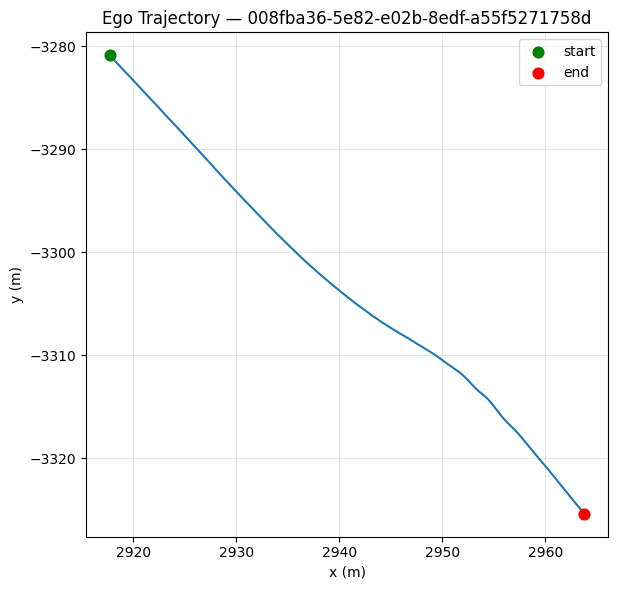

In [7]:
if scene.ego_poses:
    import matplotlib.pyplot as plt

    positions = np.array([p.translation for p in scene.ego_poses])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(positions[:, 0], positions[:, 1], linewidth=1.5)
    ax.scatter(positions[0, 0], positions[0, 1], c="green", s=60, zorder=5, label="start")
    ax.scatter(positions[-1, 0], positions[-1, 1], c="red", s=60, zorder=5, label="end")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(f"Ego Trajectory — {scene.scene_id}")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No ego poses available in poses.txt for this scene.")

## 7. Iterate over all scenes

The dataset supports `len()`, indexing, and iteration.

In [8]:
print(f"{'Scene ID':<40} {'Frames':>8} {'Duration (s)':>14} {'Ego poses':>11} {'Sensors':>9}")
print("-" * 90)
for s in ds:
    print(
        f"{s.scene_id:<40} {s.metadata.num_frames:>8} "
        f"{s.metadata.duration_s:>14.2f} {len(s.ego_poses):>11} "
        f"{len(s.metadata.sensor_names):>9}"
    )

Scene ID                                   Frames   Duration (s)   Ego poses   Sensors
------------------------------------------------------------------------------------------
008fba36-5e82-e02b-8edf-a55f5271758d          130          12.90         130        19
00efe646-1e8f-cadc-d642-e676781187ef          150          14.90         150        19
00fc1b9b-005e-554c-7733-c4c0adeca015          100           9.90         100        19
02be7d74-6f74-9167-c8a2-84fc961c0fbd          100           9.90         100        19
03ed2585-0729-92ad-98af-fdd9ac1c3a80          200          19.90         200        19
04a39028-c434-6cff-b3f4-9f8dbb9aa078          280          27.90         280        19
0638dbd2-172d-142e-de9f-9bc5c6ca2b0f          100           9.90         100        19
0cfdeb83-2a4a-00d2-a500-787346d98e63          180          17.90         180        19
0dd003b2-0988-0da3-bf75-ee91deaa9ce6          120          11.90         120        19
0f8ffa88-e84d-eaa2-4ef1-62bb539f8e03   

## 8. Flat frame access — map-style dataset

`FrameDataset` flattens all scenes into a single index, implementing the `__len__` / `__getitem__` interface that `torch.utils.data.DataLoader` (and any other sampler) expects.

In [9]:
import os

os.environ["KITSCENES_ROOT"] = DATASET_ROOT

# Now root= can be omitted.
ds2 = KITScenesDataset()
print(ds2)
print(f"Same dataset? scene_ids match: {ds.scene_ids == ds2.scene_ids}")

KITScenesDataset(root=PosixPath('/tmp/fehler/ratarmount/kitscenes'), split=None, num_scenes=11)
Same dataset? scene_ids match: True


In [10]:
frames = ds.as_frames()
print(frames)
print(f"Total frames: {len(frames)}  ({len(ds)} scenes × avg {len(frames) // len(ds)} frames)\n")

# --- Map-style access: same interface as torch.utils.data.Dataset -------------
frame = frames[0]
print(f"frames[0]:  {frame}")
print(f"  timestamp_s:       {frame.timestamp_s:.3f}")
print(f"  ego_pose:          {frame.ego_pose}")

sweep = frame.lidar_top
if sweep is not None:
    print(f"  lidar_top:         {len(sweep.points):,} points  fields={sweep.points.dtype.names}")

img = frame.camera_ring_front
if img is not None:
    print(f"  camera_ring_front: {img.shape}  dtype={img.dtype}")

# --- DataLoader-style batched iteration ---------------------------------------
# Frame objects hold variable-length point clouds, so collate_fn=list keeps
# each batch as a plain Python list rather than trying to stack into tensors.
# Replace with your own collate_fn to produce fixed-shape tensors for training.
try:
    from torch.utils.data import DataLoader

    loader = DataLoader(frames, batch_size=4, shuffle=False, collate_fn=list)
    print(f"\ntorch DataLoader — {len(loader)} batches of ≤4 frames")

    for batch_idx, batch in enumerate(loader):
        sweeps = [f.lidar_top for f in batch if f.lidar_top is not None]
        print(
            f"  batch {batch_idx:02d}: {len(batch)} frames, "
            f"{len(sweeps)} with lidar_top"
            + (f",  first sweep: {len(sweeps[0].points):,} pts" if sweeps else "")
        )
        if batch_idx >= 2:
            print(f"  ... ({len(loader) - 3} more batches)")
            break

except ImportError:
    # Without PyTorch the same iteration works directly on the FrameDataset.
    batch_size = 4
    print(f"\nManual batching (torch not installed) — batch_size={batch_size}")
    for start in range(0, min(len(frames), batch_size * 3), batch_size):
        batch = [frames[i] for i in range(start, min(start + batch_size, len(frames)))]
        sweeps = [f.lidar_top for f in batch if f.lidar_top is not None]
        print(
            f"  frames[{start}:{start + len(batch)}]: {len(batch)} frames, "
            f"{len(sweeps)} with lidar_top"
            + (f",  first sweep: {len(sweeps[0].points):,} pts" if sweeps else "")
        )

FrameDataset(num_scenes=11, num_frames=1830)
Total frames: 1830  (11 scenes × avg 166 frames)

frames[0]:  Frame(scene_id=008fba36-5e82-e02b-8edf-a55f5271758d, frame_idx=0, timestamp_ns=46100000)
  timestamp_s:       0.046
  ego_pose:          EgoPose(timestamp_ns=46052933, translation=array([ 2917.7171, -3280.8901,   167.1385]), rotation=array([ 0.0254, -0.0185, -0.3991,  0.9164]))
  lidar_top:         898,682 points  fields=('x', 'y', 'z', 'reflectivity', 'timestamp', 'ring', 'sensor_id', 'sensor_specific_data')
  camera_ring_front: (2272, 3504, 3)  dtype=uint8

Manual batching (torch not installed) — batch_size=4
  frames[0:4]: 4 frames, 4 with lidar_top,  first sweep: 898,682 pts
  frames[4:8]: 4 frames, 4 with lidar_top,  first sweep: 898,730 pts
  frames[8:12]: 4 frames, 4 with lidar_top,  first sweep: 898,978 pts
